在实际的大规模训练中，MoE 并行通常不会单独使用，而是与 TP (张量并行), PP (流水并行), DP (数据并行) 组合，形成 4D 并行。

| 并行维度 | 作用对象 | 在 MoE 中的角色 |
| :--- | :--- | :--- |
| EP (Expert Parallelism) | 专家层 | 将不同的专家切分到不同卡。这是 MoE 独有的。 |
| TP (Tensor Parallelism) | 专家内部 / 共享层 | 如果单个专家太大，可以在专家内部继续做矩阵切分 (TP)。或者在非 MoE 层（如 Attention 层）使用 TP。 |
| PP (Pipeline Parallelism) | 模型层 | 将 MoE 层和其他层按深度切分到不同节点。 |
| DP (Data Parallelism) | 批次数据 | 复制整个模型结构（包含分片后的专家），处理不同的数据批次。通常在 DP 组内再做一次专家分片（即 ZeRO + MoE）。 |



In [2]:
from IPython.display import Image

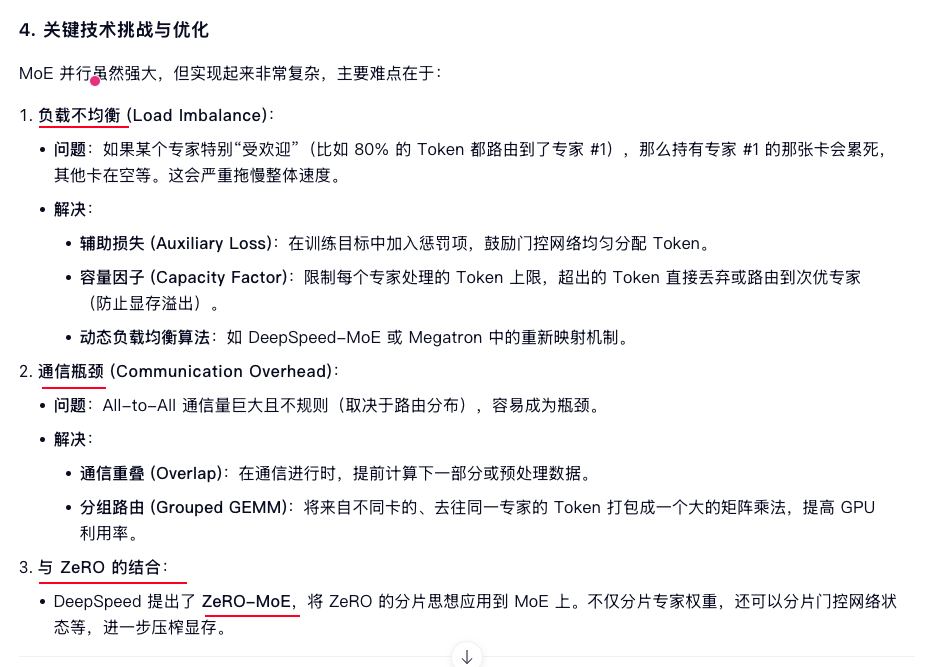

In [3]:
Image(filename='moe.png')

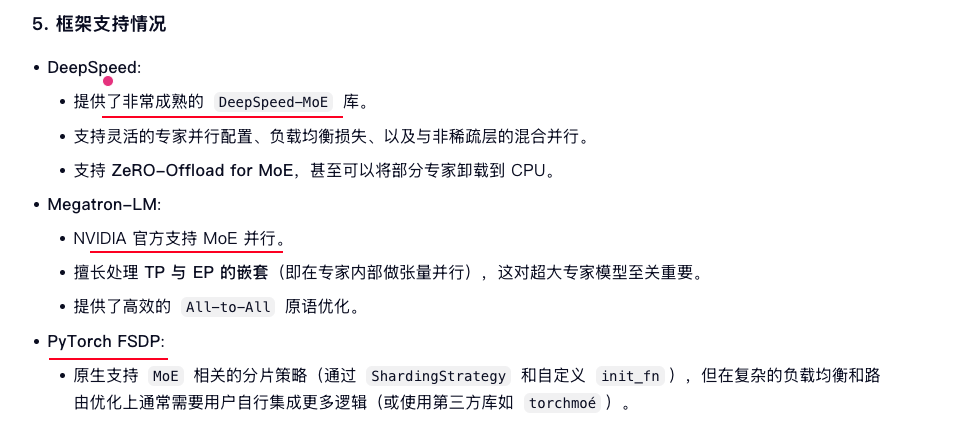

In [5]:
Image(filename='moe1.png')